In [1]:
import matplotlib.patches as patches
import sys
sys.path.append("../src/")
from constrained_likelihood_surrogates import *

default_col_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

line_style_list = ['-', '--', '-.', ':', '-', (0, (3, 5, 1, 5, 1, 5))]
col_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:red', 'tab:gray', 'tab:olive', 'tab:cyan']

In [2]:
# # Load results for plots vs N for the usual number of transitions

test_type = 'power'

load_folder_name = './results/hyp-test/benchmarking/'

N_list = [2**n for n in range(2, 11)]
num_N = len(N_list)
N_tick_list = N_list[::4]

lower_cutoff = 1
num_surr = 19
num_tests = 10**3
num_free_stats, num_depe_stats = 12, 7
process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_processes = len(process_list)
model_list = process_list
num_models = len(model_list)
# method_list = ['constrained', 'typical', 'sign', 'CLT']
method_list = ['constrained', 'typical']
num_methods = len(method_list)

surr_time_mat = np.full((num_N, num_methods, num_processes, num_models, num_tests), np.nan)#Average time per surrogate: num_N x num_methods x num_processes x num_models x num_tests
param_fit_time_mat = np.full((num_N, num_processes, num_models, num_tests), np.nan)#Time to calculate maximum likelihood parameters: num_N x num_processes x num_models x num_tests

free_quantile_mat = np.full((num_N, num_methods, num_processes, num_models, num_tests, num_free_stats), np.nan)#Array of nans: num_N x num_methods x num_processes x num_models x num_tests x num_free_stats
depe_quantile_mat = np.full((num_N, num_methods, num_processes, num_models, num_tests, num_depe_stats), np.nan)#Array of nans: num_N x num_methods x num_processes x num_models x num_tests x num_free_stats

process_str = '_p-1.5_l--1-1_e-1_t--1-1_u-9'

for i_N in range(num_N):
    N = N_list[i_N]
    num_trans = N*(int(np.ceil(np.log2(N*1024))))#r = 2\tilde{r}
    
    save_str_0 = 'time_quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff) + '_N-' + str(N) + '_ntra-' + str(num_trans) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_npro-' + str(num_processes) + '_nmod-' + str(num_models) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats)
    save_str = save_str_0 + process_str
    with open(load_folder_name + save_str + '.json', 'r') as read_file:
        save_dict = json.load(read_file)

    #Times:
    surr_time_list_list_list = np.array(save_dict['surr_time_list_list_list'])#num_methods x num_processes x num_models x num_tests
    surr_time_mat[i_N, :, :, :, :] = surr_time_list_list_list#num_N x num_methods x num_processes x num_models x num_tests

    param_fit_time_list_list_list = np.array(save_dict['param_fit_time_list_list_list'])#num_processes x num_models x num_tests
    param_fit_time_mat[i_N, :, :, :] = param_fit_time_list_list_list#num_N x num_processes x num_models x num_tests

    #Quantiles:
    free_quantile_list_list_list = np.array(save_dict['free_quantile_list_list_list'])#num_methods x num_processes x num_models x num_tests x num_free_stats
    free_quantile_mat[i_N, :, :, :, :, :] = free_quantile_list_list_list# num_N x num_methods x num_processes x num_models x num_tests x num_free_stats
    
    depe_quantile_list_list_list = np.array(save_dict['depe_quantile_list_list_list'])#num_methods x num_processes x num_models x num_tests x num_depe_stats
    depe_quantile_mat[i_N, :, :, :, :, :] = depe_quantile_list_list_list# num_N x num_methods x num_processes x num_models x num_tests x num_depe_stats
    
    N = save_dict['N']
    num_trans = save_dict['num_trans']
    save_str = save_dict['save_str']
    depe_stat_name_list = save_dict['depe_stat_name_list']
    
test_type = save_dict['test_type']
lower_cutoff = save_dict['lower_cutoff']
num_surr = save_dict['num_surr']
num_tests = save_dict['num_tests']
num_methods = save_dict['num_methods']
process_list = save_dict['process_list']
model_list = save_dict['model_list']
free_stat_name_list = save_dict['free_stat_name_list']
depe_stat_name_list = save_dict['depe_stat_name_list']

nominal_size = 0.10

kL, kU = binom.interval(0.90, num_tests, nominal_size)
pL, pU = kL/num_tests, kU/num_tests

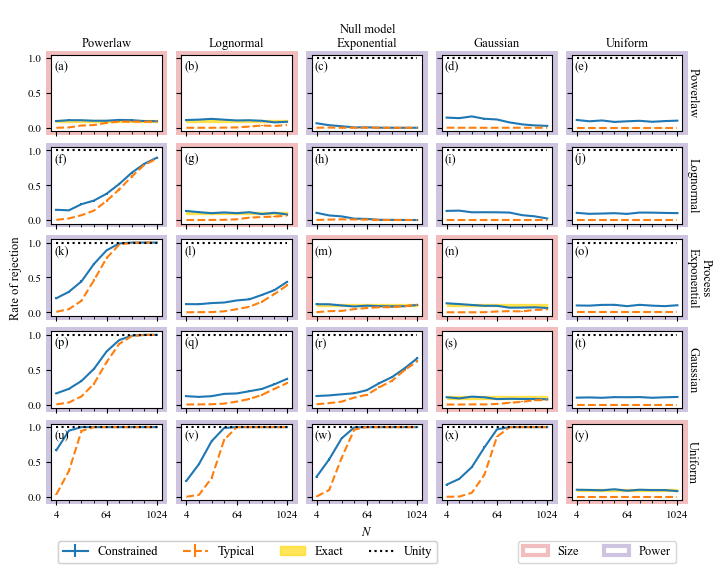

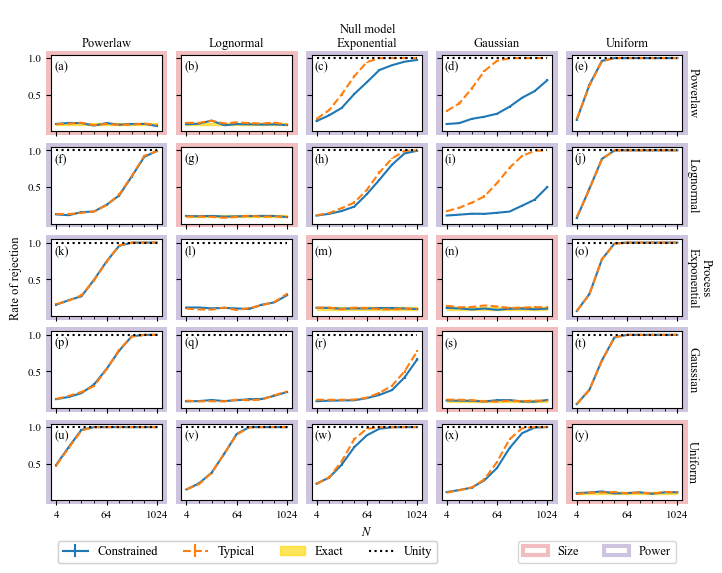

In [3]:
# process_list: ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']

# Plot POWER and SIZE:

# For coloured rectangle:
a_hori = 0.05;
a_vert = 0.05;
alph = 0.3
exact_alpha = 0.6
size_col = 'tab:red'#'#f28e8e'
power_col = '#5e3c99'#'tab:purple'#'#A89BBF'#grey-purple

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

# stat_type_list = ['free', 'free', 'free', 'free', 'depe']#max, max, coef. var., skewness, KS
# side_list = ['left-tailed', 'right-tailed', 'two-sided', 'two-sided', 'right-tailed']#max, max, coef. var., skewness, KS
# i_stat_list = [4, 4, 6, 8, 0]#max, max, coef. var., skewness, KS
stat_type_list = ['free', 'depe']#max, KS
side_list = ['left-tailed', 'right-tailed']#max, KS
i_stat_list = [4, 0]#max, KS
num_stats_to_consider = len(i_stat_list)

for i_stats_to_consider in range(num_stats_to_consider):
    stat_type = stat_type_list[i_stats_to_consider]
    i_stat = i_stat_list[i_stats_to_consider]
    side = side_list[i_stats_to_consider]
    
    if (stat_type == 'free'):
        stat_name_list = free_stat_name_list
        quantile_mat = free_quantile_mat
    elif (stat_type == 'depe'):
        stat_name_list = depe_stat_name_list
        quantile_mat = depe_quantile_mat
    num_stats = len(stat_name_list)
    
    if (side == 'left-tailed'):
        rej_mat = (quantile_mat < nominal_size)# num_N x num_methods x num_processes x num_models x num_tests x num_stats
    elif (side == 'right-tailed'):
        rej_mat = (quantile_mat > (1 - nominal_size))# num_N x num_methods x num_processes x num_models x num_tests x num_stats
    elif (side == 'two-sided'):
        rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_processes x num_models x num_tests x num_stats
        
    rej_rate_mat = np.sum(rej_mat, axis=4)/num_tests# num_N x num_methods x num_processes x num_models x num_free_stats
    
    stat = stat_name_list[i_stat]

    fig_width = 7.0
    fig, ax_array = plt.subplots(num_processes, num_models, sharex=True, sharey=True, figsize=(fig_width, num_processes))
    fig.tight_layout(pad=0.5)
    for i_process in range(num_processes):
        process = process_list[i_process]
        # ax_array[i_process][0].set_title(r'null model:                             ')
        meth_to_consider_list = [0, 1]
        #models_to_consider_list = list(set(range(num_models)).difference({i_process}))
        models_to_consider_list = list(range(num_models))
        for i_model in models_to_consider_list:
            model = model_list[i_model]
            ax = ax_array[i_process][i_model]
            for i_method in meth_to_consider_list:#['const.', 'typic.', 'sign', 'clt']
                method = method_list[i_method]
                method_name = beautify_method_name(method)
                rej_rate_list = rej_rate_mat[:, i_method, i_process, i_model, i_stat]
                err_list = np.sqrt(rej_rate_list*(1 - rej_rate_list)/num_tests)
                ax.errorbar(N_list, rej_rate_list, err_list, label=method_name, color=col_list[i_method], linestyle=line_style_list[i_method])
            if (i_process == 0):
                if (2*i_model + 1 == num_models):
                    ax.set_title('\nNull model\n' + beautify_distribution_name(model))
                else:
                    ax.set_title('\n' + beautify_distribution_name(model))
            if (i_model == 0) and (2*i_process + 1 == num_processes):
                ax.set_ylabel('Rate of rejection')
                # if (2*i_process + 1 == num_processes):
                #     ax.set_ylabel('process\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
                # else:
                #     ax.set_ylabel('\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
            if (i_model == (num_models - 1)):
                x = ax.get_position().x1 + 0.025#For right label
                y = (ax.get_position().y0 + ax.get_position().y1)/2#For right label
                if (2*i_process + 1 == num_processes):
                    fig.text(x, y, 'Process\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
                else:
                    fig.text(x, y, '\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
            if (i_model == i_process) or ([i_process, i_model] == [0, 1]) or ([i_process, i_model] == [2, 3]):
                ax.fill_between([min(N_list), max(N_list)], [pL, pL], [pU, pU], color='gold', alpha=exact_alpha, label='Exact')
                ax.errorbar([], [], linestyle=':', color='k', label='unity')
                panel_colour = size_col
            else:
                ax.fill_between([], [], [], color='gold', alpha=exact_alpha, label='Exact')
                ax.errorbar([min(N_list), max(N_list)], [1, 1], linestyle=':', color='k', label='Unity')
                panel_colour = power_col
            pos = ax.get_position()  # Bbox in *figure* coordinates
            rect = patches.Rectangle((pos.x0 - a_hori*pos.width, pos.y0 - a_vert*pos.width), pos.width + 2*a_hori*pos.width, pos.height + 2*a_vert*pos.width,
                                     transform=fig.transFigure, facecolor=panel_colour, alpha=alph, edgecolor='none', zorder=0, clip_on=False)
            fig.add_artist(rect)     # add to the figure background
            if (i_process == num_processes - 1) and (2*i_model + 1 == num_models):
                ax.set_xlabel('$N$')
        ax.set_xscale('log')
        ax.xaxis.set_minor_locator(LogLocator(base=2, numticks=num_N + 1))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xticks(N_tick_list)
        ax.set_xticklabels(N_tick_list)
        x_lim = [min(N_list)*(max(N_list)/min(N_list))**-0.05, max(N_list)*(max(N_list)/min(N_list))**+0.05]
        ax.set_xlim(x_lim)
    
    y_leg = -0.90
    ax = ax_array[num_processes - 1][0]
    ax.legend(ncol=4, loc='lower left', bbox_to_anchor=(0, -0.6))
    handles, labels = ax.get_legend_handles_labels()
    order = [1, 2, 0, 3]  # indices into handles/labels
    leg1 = ax.legend([handles[i] for i in order], [labels[i] for i in order], ncol=4, loc='lower left', bbox_to_anchor=(0, y_leg))
    ax.add_artist(leg1)
    ax = ax_array[num_processes - 1][num_models - 1]
    mpatches = [patches.Patch(facecolor='white', edgecolor=size_col, linewidth=3, alpha=alph, label='Size'), patches.Patch(facecolor='white', edgecolor=power_col, linewidth=3, alpha=0.3, label='Power')]
    leg2 = ax.legend(handles=mpatches, ncol=2, loc='lower right', bbox_to_anchor=(1, y_leg))
    
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    scale = fig.get_figwidth()/bbox.width
    fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

    label_subplots(ax_array, corner='upper left', offset=(2, -4), order='row-major')
    
    fig_name_str = 'power-vs-N_usual-n_from-' + stat + '_' + side + '_' + str(num_processes) + 'processes'
    plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
    plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')
    plt.show()

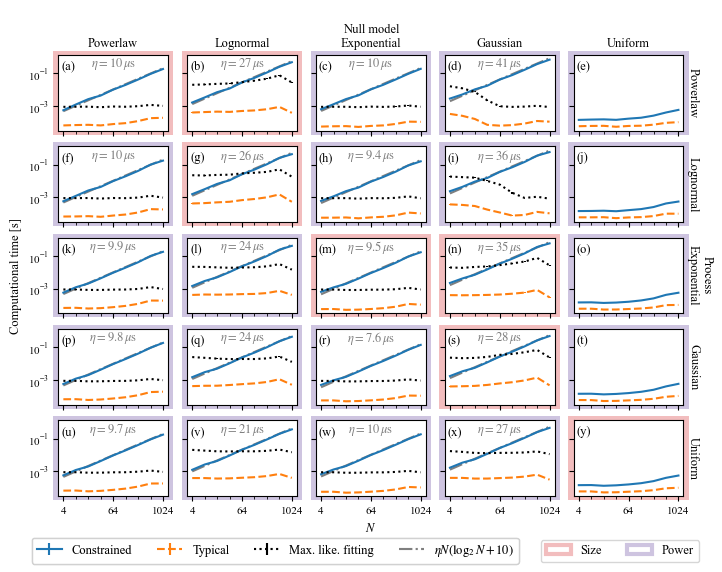

In [4]:
# process_list: ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']

# Plot COMPUTATIONAL TIME used to compute power and size

# For coloured rectangle:
a_hori = 0.05;
a_vert = 0.05;
alph = 0.3
exact_alpha = 0.6
size_col = 'tab:red'#'#f28e8e'
power_col = '#5e3c99'#'tab:purple'#'#A89BBF'#grey-purple

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

N_log_N_plus_10_list = np.array(N_list)*(np.log2(N_list) + 10)
eta_label_offset = (0, -1)#Offset from top centre of axis [points]

fig_width = 7.0
fig, ax_array = plt.subplots(num_processes, num_models, sharex=True, sharey=True, figsize=(fig_width, num_processes))
fig.tight_layout(pad=0.5)
for i_process in range(num_processes):
    process = process_list[i_process]
    # ax_array[i_process][0].set_title(r'null model:                             ')
    meth_to_consider_list = [0, 1]
    #models_to_consider_list = list(set(range(num_models)).difference({i_process}))
    models_to_consider_list = list(range(num_models))
    for i_model in models_to_consider_list:
        model = model_list[i_model]
        ax = ax_array[i_process][i_model]
        for i_method in meth_to_consider_list:#['const.', 'typic.', 'sign', 'clt']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            time_list = np.mean(surr_time_mat[:, i_method, i_process, i_model, :], axis=1)
            err_time_list = np.std(surr_time_mat[:, i_method, i_process, i_model, :], axis=1)/np.sqrt(num_tests)
            ax.errorbar(N_list, time_list, err_time_list, label=method_name, color=col_list[i_method], linestyle=line_style_list[i_method])
            if (i_method == 0):
                constrained_time_list = time_list
        fit_time_list = np.mean(param_fit_time_mat[:, i_process, i_model, :], axis=1)
        if (i_model < 4):
            err_fit_time_list = np.std(param_fit_time_mat[:, i_process, i_model, :], axis=1)/np.sqrt(num_tests)
            ax.errorbar(N_list, fit_time_list, err_fit_time_list, label='Max. like. fitting', color='k', linestyle=':')
            a = np.exp(np.mean(np.log(constrained_time_list) - np.log(N_log_N_plus_10_list)))#Least-squares fit with y on logarithmic scale
            N_log_N_plus_10_fit_list = a*N_log_N_plus_10_list
            ax.plot(N_list, N_log_N_plus_10_fit_list, label=r'$\eta N(\log_2 N + 10)$', color='tab:gray', linestyle='-.')
            eta = 10**6*a#Microseconds per transition
            ax.annotate(r'$\eta=' + '{:.2g}'.format(eta) + r'\,\mu\mathrm{s}$', xy=(0.5, 1), xycoords='axes fraction', xytext=eta_label_offset, textcoords='offset points', ha='center', va='top', color='tab:gray', fontsize=label_font_size)
        if (i_process == 0):
            if (2*i_model + 1 == num_models):
                ax.set_title('\nNull model\n' + beautify_distribution_name(model))
            else:
                ax.set_title('\n' + beautify_distribution_name(model))
        if (i_model == 0) and (2*i_process + 1 == num_processes):
            ax.set_ylabel('Computational time [s]')
            # if (2*i_process + 1 == num_processes):
            #     ax.set_ylabel('process\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
            # else:
            #     ax.set_ylabel('\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
        if (i_model == (num_models - 1)):
            x = ax.get_position().x1 + 0.025#For right label
            y = (ax.get_position().y0 + ax.get_position().y1)/2#For right label
            if (2*i_process + 1 == num_processes):
                fig.text(x, y, 'Process\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
            else:
                fig.text(x, y, '\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
        if (i_model == i_process) or ([i_process, i_model] == [0, 1]) or ([i_process, i_model] == [2, 3]):
            panel_colour = size_col
        else:
            panel_colour = power_col
        pos = ax.get_position()  # Bbox in *figure* coordinates
        rect = patches.Rectangle((pos.x0 - a_hori*pos.width, pos.y0 - a_vert*pos.width), pos.width + 2*a_hori*pos.width, pos.height + 2*a_vert*pos.width, transform=fig.transFigure, facecolor=panel_colour, alpha=alph, edgecolor='none', zorder=0, clip_on=False)
        fig.add_artist(rect)     # add to the figure background
        if (i_process == num_processes - 1) and (2*i_model + 1 == num_models):
            ax.set_xlabel('$N$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_minor_locator(LogLocator(base=2, numticks=num_N + 1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xticks(N_tick_list)
    ax.set_xticklabels(N_tick_list)
    x_lim = [min(N_list)*(max(N_list)/min(N_list))**-0.05, max(N_list)*(max(N_list)/min(N_list))**+0.05]
    ax.set_xlim(x_lim)

y_leg = -0.95
ax = ax_array[num_processes - 1][0]
ax.legend(ncol=4, loc='lower left', bbox_to_anchor=(0, y_leg))
handles, labels = ax.get_legend_handles_labels()
legend_order = [1, 2, 3, 0]#Constrained, typical, max. like. fitting, N log N
handles = [handles[i] for i in legend_order]
labels = [labels[i] for i in legend_order]
leg1 = ax.legend(handles, labels, ncol=4, loc='lower left', bbox_to_anchor=(-0.3, y_leg - 0.02))
ax.add_artist(leg1)
ax = ax_array[num_processes - 1][num_models - 1]
mpatches = [patches.Patch(facecolor='white', edgecolor=size_col, linewidth=3, alpha=alph, label='Size'), patches.Patch(facecolor='white', edgecolor=power_col, linewidth=3, alpha=0.3, label='Power')]
leg2 = ax.legend(handles=mpatches, ncol=2, loc='lower right', bbox_to_anchor=(1.2, y_leg))

bbox = fig.get_tightbbox(fig.canvas.get_renderer())
scale = fig.get_figwidth()/bbox.width
fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

label_subplots(ax_array, corner='upper left', offset=(2, -4), order='row-major')

fig_name_str = 'computational-time-vs-N_usual-n-trans'
plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')
plt.show()

In [5]:
# # Find number of transitions for which results are available for each combination of num_tests and N

test_type = 'power'

load_folder_name = './results/hyp-test/benchmarking/'

lower_cutoff = 1
num_surr = 19
num_free_stats, num_depe_stats = 12, 7
process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_processes = len(process_list)
model_list = process_list
num_models = len(model_list)
method_list = ['constrained', 'typical']
num_methods = len(method_list)

for num_tests in [100, 1000]:
    print('num_tests=' + str(num_tests) + ':')
    for N in [2**n for n in range(11)]:
        print('\tN=' + str(N) + ':')
        
        save_str_left = 'time_quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff) + '_N-' + str(N) + '_ntra-'
        process_str = '_p-1.5_l--1-1_e-1_t--1-1_u-9'
        save_str_right = '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_npro-' + str(num_processes) + '_nmod-' + str(num_models) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats) + process_str
        
        num_trans_potential_list = [2**n for n in range(2*30)];
        num_trans_list = [num_trans for num_trans in num_trans_potential_list if exists(load_folder_name + save_str_left + str(num_trans) + save_str_right + '.json')]#Load all available num_trans
        print('\t\tFor N=' + str(N) + ', num_tests=' + str(num_tests) + ', results for num_trans in ' + str(num_trans_list))

num_tests=100:
	N=1:
		For N=1, num_tests=100, results for num_trans in []
	N=2:
		For N=2, num_tests=100, results for num_trans in []
	N=4:
		For N=4, num_tests=100, results for num_trans in []
	N=8:
		For N=8, num_tests=100, results for num_trans in []
	N=16:
		For N=16, num_tests=100, results for num_trans in []
	N=32:
		For N=32, num_tests=100, results for num_trans in []
	N=64:
		For N=64, num_tests=100, results for num_trans in []
	N=128:
		For N=128, num_tests=100, results for num_trans in []
	N=256:
		For N=256, num_tests=100, results for num_trans in []
	N=512:
		For N=512, num_tests=100, results for num_trans in []
	N=1024:
		For N=1024, num_tests=100, results for num_trans in []
num_tests=1000:
	N=1:
		For N=1, num_tests=1000, results for num_trans in []
	N=2:
		For N=2, num_tests=1000, results for num_trans in []
	N=4:
		For N=4, num_tests=1000, results for num_trans in []
	N=8:
		For N=8, num_tests=1000, results for num_trans in []
	N=16:
		For N=16, num_tests=1000, result

In [6]:
# # Load results for plots vs number of transitions for fixed N

test_type = 'power'

load_folder_name = './results/hyp-test/benchmarking/'

lower_cutoff = 1
num_surr = 19
num_free_stats, num_depe_stats = 12, 7
process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_processes = len(process_list)
model_list = process_list
num_models = len(model_list)
method_list = ['constrained', 'typical']
num_methods = len(method_list)

# num_tests = 10**3; N = 1024; max_r_factor = 64
# num_tests = 10**3; N = 256; max_r_factor = 64
# num_trans_list = [(2**n)*N for n in range(1 + int(np.round(np.log2(max_r_factor))))]#Original: selected multiples of N

# N = 16; num_tests = 100
# N = 32; num_tests = 100
# N = 64; num_tests = 100
# N = 128; num_tests = 100
# N = 256; num_tests = 100

# N = 16; num_tests = 1000
# N = 32; num_tests = 1000
N = 64; num_tests = 1000

save_str_left = 'time_quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff) + '_N-' + str(N) + '_ntra-'
process_str = '_p-1.5_l--1-1_e-1_t--1-1_u-9'
save_str_right = '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_npro-' + str(num_processes) + '_nmod-' + str(num_models) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats) + process_str

num_trans_potential_list = [2**n for n in range(2*30)];
num_trans_list = [num_trans for num_trans in num_trans_potential_list if exists(load_folder_name + save_str_left + str(num_trans) + save_str_right + '.json')]#Load all available num_trans
print('N=' + str(N) + ', num_tests=' + str(num_tests) + ', and num_trans in ' + str(num_trans_list) + ':\nLoaded ' + save_str_left + 'num_trans' + save_str_right + '.json')

num_num_trans = len(num_trans_list)
num_trans_tick_list = num_trans_potential_list[::4]

recommm_num_trans = (int(np.ceil(N/2*np.log2(N*1024))))

surr_time_mat = np.full((num_num_trans, num_methods, num_processes, num_models, num_tests), np.nan)#Average time per surrogate: num_N x num_methods x num_processes x num_models x num_tests
param_fit_time_mat = np.full((num_num_trans, num_processes, num_models, num_tests), np.nan)#Time to calculate maximum likelihood parameters: num_N x num_processes x num_models x num_tests

free_quantile_mat = np.full((num_num_trans, num_methods, num_processes, num_models, num_tests, num_free_stats), np.nan)#Array of nans: num_N x num_methods x num_processes x num_models x num_tests x num_free_stats
depe_quantile_mat = np.full((num_num_trans, num_methods, num_processes, num_models, num_tests, num_depe_stats), np.nan)#Array of nans: num_N x num_methods x num_processes x num_models x num_tests x num_free_stats

for i_num_trans in range(num_num_trans):
    num_trans = num_trans_list[i_num_trans]

    save_str = save_str_left + str(num_trans) + save_str_right
    with open(load_folder_name + save_str + '.json', 'r') as read_file:
        save_dict = json.load(read_file)

    #Times:
    surr_time_list_list_list = np.array(save_dict['surr_time_list_list_list'])#num_methods x num_processes x num_models x num_tests
    surr_time_mat[i_num_trans, :, :, :, :] = surr_time_list_list_list#num_num_trans x num_methods x num_processes x num_models x num_tests

    param_fit_time_list_list_list = np.array(save_dict['param_fit_time_list_list_list'])#num_processes x num_models x num_tests
    param_fit_time_mat[i_num_trans, :, :, :] = param_fit_time_list_list_list#num_num_trans x num_processes x num_models x num_tests

    #Quantiles:
    free_quantile_list_list_list = np.array(save_dict['free_quantile_list_list_list'])#num_methods x num_processes x num_models x num_tests x num_free_stats
    free_quantile_mat[i_num_trans, :, :, :, :, :] = free_quantile_list_list_list# num_num_trans x num_methods x num_processes x num_models x num_tests x num_free_stats
    
    depe_quantile_list_list_list = np.array(save_dict['depe_quantile_list_list_list'])#num_methods x num_processes x num_models x num_tests x num_depe_stats
    depe_quantile_mat[i_num_trans, :, :, :, :, :] = depe_quantile_list_list_list# num_num_trans x num_methods x num_processes x num_models x num_tests x num_depe_stats
    
    N = save_dict['N']
    num_trans = save_dict['num_trans']
    save_str = save_dict['save_str']
    depe_stat_name_list = save_dict['depe_stat_name_list']
    
test_type = save_dict['test_type']
lower_cutoff = save_dict['lower_cutoff']
num_surr = save_dict['num_surr']
num_tests = save_dict['num_tests']
num_methods = save_dict['num_methods']
process_list = save_dict['process_list']
model_list = save_dict['model_list']
free_stat_name_list = save_dict['free_stat_name_list']
depe_stat_name_list = save_dict['depe_stat_name_list']

nominal_size = 0.1
kL, kU = binom.interval(0.90, num_tests, nominal_size)
pL, pU = kL/num_tests, kU/num_tests

N=64, num_tests=1000, and num_trans in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]:
Loaded time_quant_free-depe_power_xmin-1_N-64_ntra-num_trans_nsur-19_ntes-1000_ntyp-2_npro-5_nmod-5_nfs-12_nds-7_p-1.5_l--1-1_e-1_t--1-1_u-9.json


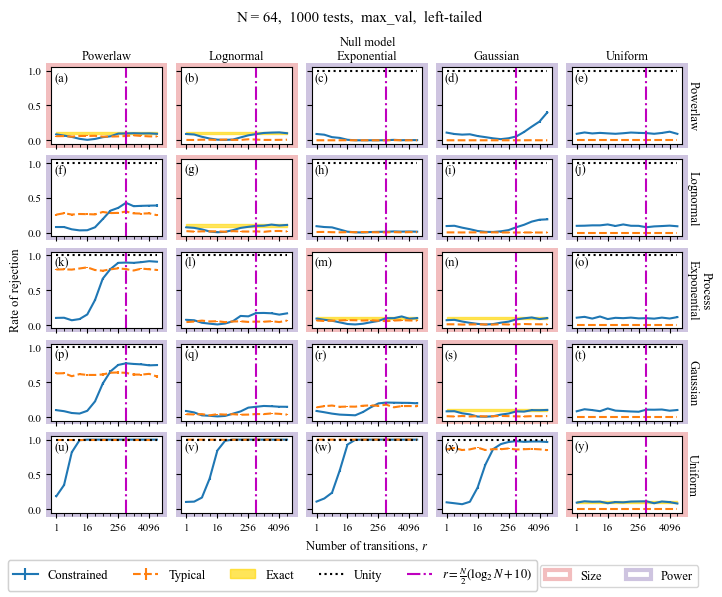

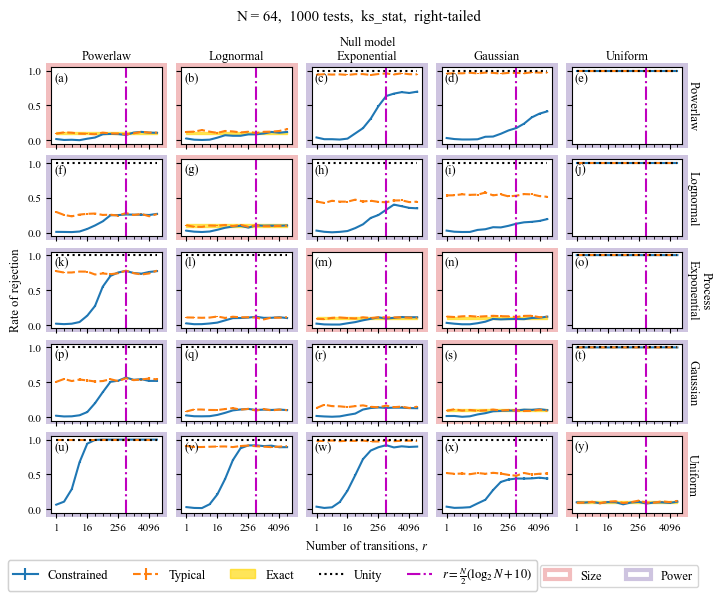

In [7]:
# process_list: ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']

# Plot POWER and SIZE:

# For coloured rectangle:
a_hori = 0.05;
a_vert = 0.05;
alph = 0.3
exact_alpha = 0.6
size_col = 'tab:red'#'#f28e8e'
power_col = '#5e3c99'#'tab:purple'#'#A89BBF'#grey-purple

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

# stat_type_list = ['free', 'free', 'free', 'free', 'depe']#max, max, coef. var., skewness, KS
# side_list = ['left-tailed', 'right-tailed', 'two-sided', 'two-sided', 'right-tailed']#max, max, coef. var., skewness, KS
# i_stat_list = [4, 4, 6, 8, 0]#max, max, coef. var., skewness, KS
stat_type_list = ['free', 'depe']#max, KS
side_list = ['left-tailed', 'right-tailed']#max, KS
i_stat_list = [4, 0]#max, KS
num_stats_to_consider = len(i_stat_list)

for i_stats_to_consider in range(num_stats_to_consider):
    stat_type = stat_type_list[i_stats_to_consider]
    i_stat = i_stat_list[i_stats_to_consider]
    side = side_list[i_stats_to_consider]
    
    if (stat_type == 'free'):
        stat_name_list = free_stat_name_list
        quantile_mat = free_quantile_mat
    elif (stat_type == 'depe'):
        stat_name_list = depe_stat_name_list
        quantile_mat = depe_quantile_mat
    num_stats = len(stat_name_list)
    
    if (side == 'left-tailed'):
        rej_mat = (quantile_mat < nominal_size)# num_N x num_methods x num_processes x num_models x num_tests x num_stats
    elif (side == 'right-tailed'):
        rej_mat = (quantile_mat > (1 - nominal_size))# num_N x num_methods x num_processes x num_models x num_tests x num_stats
    elif (side == 'two-sided'):
        rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_processes x num_models x num_tests x num_stats
        
    rej_rate_mat = np.sum(rej_mat, axis=4)/num_tests# num_N x num_methods x num_processes x num_models x num_free_stats
    
    stat = stat_name_list[i_stat]

    fig_width = 7.0
    fig, ax_array = plt.subplots(num_processes, num_models, sharex=True, sharey=True, figsize=(fig_width, num_processes))
    fig.tight_layout(pad=0.5)
    for i_process in range(num_processes):
        process = process_list[i_process]
        # ax_array[i_process][0].set_title(r'null model:                             ')
        meth_to_consider_list = [0, 1]
        #models_to_consider_list = list(set(range(num_models)).difference({i_process}))
        models_to_consider_list = list(range(num_models))
        for i_model in models_to_consider_list:
            model = model_list[i_model]
            ax = ax_array[i_process][i_model]
            for i_method in meth_to_consider_list:#['const.', 'typic.', 'sign', 'clt']
                method = method_list[i_method]
                method_name = beautify_method_name(method)
                rej_rate_list = rej_rate_mat[:, i_method, i_process, i_model, i_stat]
                err_list = np.sqrt(rej_rate_list*(1 - rej_rate_list)/num_tests)
                ax.errorbar(num_trans_list, rej_rate_list, err_list, label=method_name, color=col_list[i_method], linestyle=line_style_list[i_method])
            if (i_process == 0):
                if (2*i_model + 1 == num_models):
                    ax.set_title('\nNull model\n' + beautify_distribution_name(model))
                else:
                    ax.set_title('\n' + beautify_distribution_name(model))
            if (i_model == 0) and (2*i_process + 1 == num_processes):
                ax.set_ylabel('Rate of rejection')
                # if (2*i_process + 1 == num_processes):
                #     ax.set_ylabel('process\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
                # else:
                #     ax.set_ylabel('\n' + beautify_distribution_name(process) + '\n' + 'rate of rejection')
            if (i_model == (num_models - 1)):
                x = ax.get_position().x1 + 0.025#For right label
                y = (ax.get_position().y0 + ax.get_position().y1)/2#For right label
                if (2*i_process + 1 == num_processes):
                    fig.text(x, y, 'Process\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
                else:
                    fig.text(x, y, '\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
            if (i_model == i_process) or ([i_process, i_model] == [0, 1]) or ([i_process, i_model] == [2, 3]):
                ax.fill_between([min(num_trans_list), max(num_trans_list)], [pL, pL], [pU, pU], color='gold', alpha=exact_alpha, label='Exact')
                ax.errorbar([], [], linestyle=':', color='k', label='unity')
                panel_colour = size_col
            else:
                ax.fill_between([], [], [], color='gold', alpha=exact_alpha, label='Exact')
                ax.errorbar([min(num_trans_list), max(num_trans_list)], [1, 1], linestyle=':', color='k', label='Unity')
                panel_colour = power_col
            pos = ax.get_position()  # Bbox in *figure* coordinates
            rect = patches.Rectangle((pos.x0 - a_hori*pos.width, pos.y0 - a_vert*pos.width), pos.width + 2*a_hori*pos.width, pos.height + 2*a_vert*pos.width,
                                     transform=fig.transFigure, facecolor=panel_colour, alpha=alph, edgecolor='none', zorder=0, clip_on=False)
            fig.add_artist(rect)     # add to the figure background
            if (i_process == num_processes - 1) and (2*i_model + 1 == num_models):
                ax.set_xlabel('Number of transitions, $r$')
        ax.set_xscale('log')
        ax.xaxis.set_minor_locator(LogLocator(base=2, numticks=num_num_trans + 1))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xticks(num_trans_tick_list)
        ax.set_xticklabels(num_trans_tick_list)
        x_lim = [min(num_trans_list)*(max(num_trans_list)/min(num_trans_list))**-0.05, max(num_trans_list)*(max(num_trans_list)/min(num_trans_list))**+0.05]
        ax.set_xlim(x_lim)
        y_lim = list(ax.get_ylim())
        for i_model in models_to_consider_list:
            ax = ax_array[i_process][i_model]
            ax.errorbar([recommm_num_trans, recommm_num_trans], y_lim, label=r'$r = \frac{N}{2}(\log_2 N + 10)$', color='m', linestyle='-.')
            ax.set_ylim(y_lim)
    
    y_leg = -1.05
    ax = ax_array[num_processes - 1][0]
    ax.legend()
    handles, labels = ax.get_legend_handles_labels()
    order = [1, 2, 0, 3, 4]  # indices into handles/labels
    leg1 = ax.legend([handles[i] for i in order], [labels[i] for i in order], ncol=5, loc='lower left', bbox_to_anchor=(-0.45, y_leg - 0.05))
    ax.add_artist(leg1)
    ax = ax_array[num_processes - 1][num_models - 1]
    mpatches = [patches.Patch(facecolor='white', edgecolor=size_col, linewidth=3, alpha=alph, label='Size'), patches.Patch(facecolor='white', edgecolor=power_col, linewidth=3, alpha=0.3, label='Power')]
    leg2 = ax.legend(handles=mpatches, ncol=2, loc='lower right', bbox_to_anchor=(1.2, y_leg))

    fig.suptitle(r'N = ' + str(N) + ',  ' + str(num_tests) + ' tests,  ' + stat + ',  ' + side, y=1.1)
    
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    scale = fig.get_figwidth()/bbox.width
    fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

    label_subplots(ax_array, corner='upper left', offset=(2, -3), order='row-major')
    # label_subplots(ax_array, corner='center right', offset=(-2, 0), order='row-major')
    
    fig_name_str = 'power-vs-num_trans_N-' + str(N) + '_from-' + stat + '_' + side + '_' + str(num_processes) + 'processes'
    plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
    plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')
    plt.show()

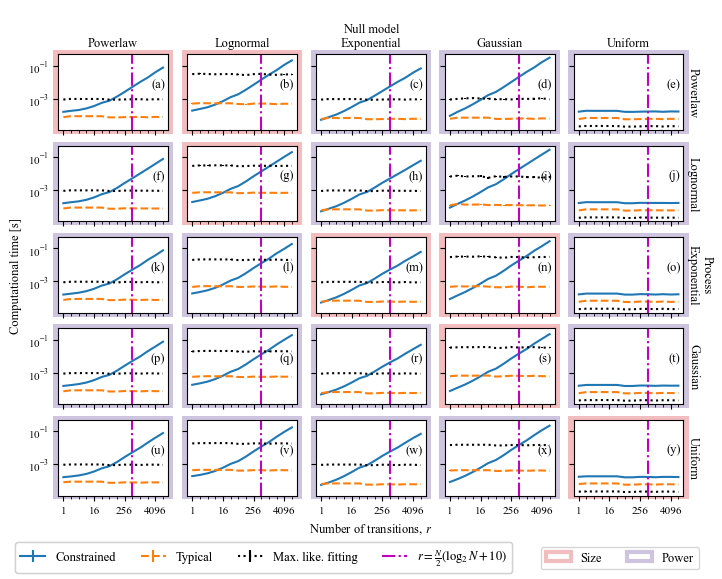

In [8]:
# process_list: ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']

# Plot COMPUTATIONAL TIME used to compute power and size

# For coloured rectangle:
a_hori = 0.05;
a_vert = 0.05;
alph = 0.3
exact_alpha = 0.6
size_col = 'tab:red'#'#f28e8e'
power_col = '#5e3c99'#'tab:purple'#'#A89BBF'#grey-purple

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

fig_width = 7.0
fig, ax_array = plt.subplots(num_processes, num_models, sharex=True, sharey=True, figsize=(fig_width, num_processes))
fig.tight_layout(pad=0.5)
for i_process in range(num_processes):
    process = process_list[i_process]
    # ax_array[i_process][0].set_title(r'null model:                             ')
    meth_to_consider_list = [0, 1]
    #models_to_consider_list = list(set(range(num_models)).difference({i_process}))
    models_to_consider_list = list(range(num_models))
    for i_model in models_to_consider_list:
        model = model_list[i_model]
        ax = ax_array[i_process][i_model]
        for i_method in meth_to_consider_list:#['const.', 'typic.', 'sign', 'clt']
            method = method_list[i_method]
            method_name = beautify_method_name(method)
            time_list = np.mean(surr_time_mat[:, i_method, i_process, i_model, :], axis=1)
            err_time_list = np.std(surr_time_mat[:, i_method, i_process, i_model, :], axis=1)/np.sqrt(num_tests)
            ax.errorbar(num_trans_list, time_list, err_time_list, label=method_name, color=col_list[i_method], linestyle=line_style_list[i_method])
        fit_time_list = np.mean(param_fit_time_mat[:, i_process, i_model, :], axis=1)
        err_fit_time_list = np.std(param_fit_time_mat[:, i_process, i_model, :], axis=1)/np.sqrt(num_tests)
        ax.errorbar(num_trans_list, fit_time_list, err_fit_time_list, label='Max. like. fitting', color='k', linestyle=':')
        if (i_process == 0):
            if (2*i_model + 1 == num_models):
                ax.set_title('\nNull model\n' + beautify_distribution_name(model))
            else:
                ax.set_title('\n' + beautify_distribution_name(model))
        if (i_model == 0) and (2*i_process + 1 == num_processes):
            ax.set_ylabel('Computational time [s]')
        if (i_model == (num_models - 1)):
            x = ax.get_position().x1 + 0.025#For right label
            y = (ax.get_position().y0 + ax.get_position().y1)/2#For right label
            if (2*i_process + 1 == num_processes):
                fig.text(x, y, 'Process\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
            else:
                fig.text(x, y, '\n' + beautify_distribution_name(process), va='center', ha='center', rotation=270, fontsize=label_font_size)
        if (i_model == i_process) or ([i_process, i_model] == [0, 1]) or ([i_process, i_model] == [2, 3]):
            panel_colour = size_col
        else:
            panel_colour = power_col
        pos = ax.get_position()  # Bbox in *figure* coordinates
        rect = patches.Rectangle((pos.x0 - a_hori*pos.width, pos.y0 - a_vert*pos.width), pos.width + 2*a_hori*pos.width, pos.height + 2*a_vert*pos.width,
                                 transform=fig.transFigure, facecolor=panel_colour, alpha=alph, edgecolor='none', zorder=0, clip_on=False)
        fig.add_artist(rect)     # add to the figure background
        if (i_process == num_processes - 1) and (2*i_model + 1 == num_models):
            ax.set_xlabel('Number of transitions, $r$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_minor_locator(LogLocator(base=2, numticks=num_num_trans + 1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xticks(num_trans_tick_list)
    ax.set_xticklabels(num_trans_tick_list)
    x_lim = [min(num_trans_list)*(max(num_trans_list)/min(num_trans_list))**-0.05, max(num_trans_list)*(max(num_trans_list)/min(num_trans_list))**+0.05]
    ax.set_xlim(x_lim)
    y_lim = list(ax.get_ylim())
    for i_model in models_to_consider_list:
        ax = ax_array[i_process][i_model]
        ax.errorbar([recommm_num_trans, recommm_num_trans], y_lim, label=r'$r = \frac{N}{2}(\log_2 N + 10)$', color='m', linestyle='-.')
        ax.set_ylim(y_lim)

y_leg = -1.05
ax = ax_array[num_processes - 1][0]
ax.legend()
handles, labels = ax.get_legend_handles_labels()
leg1 = ax.legend(handles, labels, ncol=4, loc='lower left', bbox_to_anchor=(-0.45, y_leg - 0.05))
ax.add_artist(leg1)
ax = ax_array[num_processes - 1][num_models - 1]
mpatches = [patches.Patch(facecolor='white', edgecolor=size_col, linewidth=3, alpha=alph, label='Size'), patches.Patch(facecolor='white', edgecolor=power_col, linewidth=3, alpha=0.3, label='Power')]
leg2 = ax.legend(handles=mpatches, ncol=2, loc='lower right', bbox_to_anchor=(1.2, y_leg))

bbox = fig.get_tightbbox(fig.canvas.get_renderer())
scale = fig.get_figwidth()/bbox.width
fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

# label_subplots(ax_array, corner='upper left', offset=(2, -4), order='row-major')
label_subplots(ax_array, corner='center right', offset=(-2, 6), order='row-major')

fig_name_str = 'computational-time-vs-num_trans_N-' + str(N) + '_from-' + stat + '_' + side + '_' + str(num_processes) + 'processes'
plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')
plt.show()